In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from pkasso.main import pKasso
from pkasso import protonate

In [3]:
smiles = 'CCCC(=O)O'

pk = pKasso(smiles)

pk.pH = 7.
pk._setup()
pk.acid0

pk.indices0
pk.clusters

cspace = pk.cluster_spaces[0]
for state_str, mol in cspace.mols_lib.items():
    print(state_str, mol)

pk.process_cluster(cspace, pk.pH)

# smiles = 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O'

# protonate(smiles)

1 <rdkit.Chem.rdchem.Mol object at 0x7236f36bf060>
0 <rdkit.Chem.rdchem.Mol object at 0x7236f36be8f0>


MicrostateDistribution(index_space=ProtonationIndexSpace(indices=[6], q_options=array([[1, 1, 0]]), mols_lib={'1': <rdkit.Chem.rdchem.Mol object at 0x7236f36bf060>, '0': <rdkit.Chem.rdchem.Mol object at 0x7236f36be8f0>}, base_lib={'1': {}, '0': {}}, acid_lib={'1': {6: np.float32(4.743271)}, '0': {}}), pH=7.0, state_strs=['0'], state_vecs=[array([0])], state_freqs=array([0.99449354]), state_qs=None, net_charge=None, freqs_macro=None)

In [5]:
from pka_predictor import predict_pkas_from_smiles, PredictionConfig

smiles_acid="CCCCC(=O)O"
smiles_base="CCCCC(=O)[O-]"

df = predict_pkas_from_smiles(
    smiles_acid=smiles_acid,
    smiles_base=smiles_base,
    config=PredictionConfig(write_csv=False)
)

print(df)
print(df.loc[0, "predict"])

Preprocessing /tmp/tmpr9o8os5z/smiles_56aa2878aa.tsv -> /home/sobuelow/software/unipka_minimal/smiles_56aa2878aa/smiles_56aa2878aa.lmdb
raw_data size: 1


100%|██████████| 1/1 [00:00<00:00, 20.73it/s]

smiles_56aa2878aa.lmdb process 1 lines


Running inference with fold_0
fused_multi_tensor is not installed corrected
fused_rounding is not installed corrected
fused_layer_norm is not installed corrected
fused_rms_norm is not installed corrected
fused_softmax is not installed corrected
2026-06-25 16:54:58 | INFO | unimol.inference | loading model(s) from /home/sobuelow/software/unipka_minimal/data/checkpoint_best.pt
2026-06-25 16:54:59 | INFO | unimol.tasks.unimol_pka | dictionary: 30 types
2026-06-25 16:54:59 | INFO | unimol.tasks.unimol_pka | charge dictionary: 7 types
2026-06-25 16:54:59 | INFO | unimol.inference | Namespace(no_progress_bar=False, log_interval=50, log_format='simple', tensorboard_logdir='', wandb_project='', wandb_name='', seed=1, cpu=False, fp16=True, bf16=False, bf16_sr=False, allreduce_fp32_grad=False, fp16_no_flatten_grads=False, fp16_init_scale=4, fp16_scale_window=256, fp16_scale_tolerance=0.0, min_loss_scale=0.0001, threshold_loss_scale=None, user_dir='/home/sobuelow/software/unipka_minimal/unimol', 

In [10]:
from pka_predictor import predict_pkas, PredictionConfig

df = predict_pkas("Datasets/tsv/test.tsv",
                  config=PredictionConfig(write_csv=False))
df

Preprocessing /home/sobuelow/software/Uni-pKa/Datasets/tsv/test.tsv -> /home/sobuelow/software/Uni-pKa/test/test.lmdb
raw_data size: 3


100%|██████████| 3/3 [00:00<00:00,  9.66it/s]


test.lmdb process 3 lines
Running inference with fold_0
fused_multi_tensor is not installed corrected
fused_rounding is not installed corrected
fused_layer_norm is not installed corrected
fused_rms_norm is not installed corrected
fused_softmax is not installed corrected
2026-06-25 16:00:13 | INFO | unimol.inference | loading model(s) from /home/sobuelow/software/Uni-pKa/finetune_save/fold_0/checkpoint_best.pt
2026-06-25 16:00:13 | INFO | unimol.tasks.unimol_pka | dictionary: 30 types
2026-06-25 16:00:13 | INFO | unimol.tasks.unimol_pka | charge dictionary: 7 types
2026-06-25 16:00:13 | INFO | unimol.inference | Namespace(no_progress_bar=False, log_interval=50, log_format='simple', tensorboard_logdir='', wandb_project='', wandb_name='', seed=1, cpu=False, fp16=True, bf16=False, bf16_sr=False, allreduce_fp32_grad=False, fp16_no_flatten_grads=False, fp16_init_scale=4, fp16_scale_window=256, fp16_scale_tolerance=0.0, min_loss_scale=0.0001, threshold_loss_scale=None, user_dir='/home/sobuelo

,smiles,predict,target
0,c1cc2c(cc1O)c3c(o2)C(=O)NCCC3>>O=C1NCCCc2c1oc1...,9.192400,NaN
1,FC(F)(F)c1cccc(Nc2[nH+]cnc3ccccc23)c1>>c1ccc2c...,4.113345,NaN
2,c1ccc(cc1)Cc2nnc(s2)NC(=O)c3cccs3>>O=C(Nc1nnc(...,6.835226,NaN


nan nan


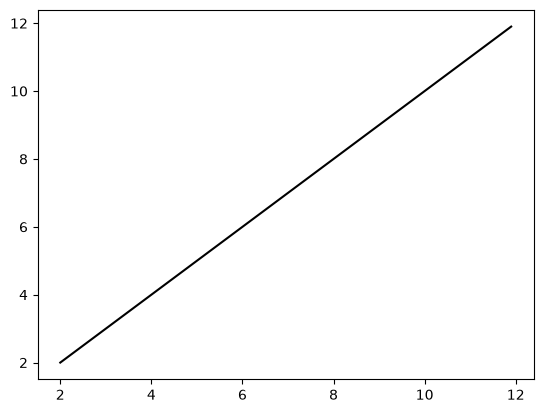

In [5]:
fig, ax = plt.subplots()
ax.plot(df['target'], df['predict'],'o')
xs = np.arange(2,12,0.1)
ax.plot(xs,xs,color='black')

mae = np.mean(np.abs(df['predict']-df['target']))
rmsd = np.sqrt(np.mean((df['predict']-df['target'])**2))
print(mae, rmsd)